In [1]:
!pip install -q ultralytics opencv-python-headless scipy matplotlib
!pip install -q --upgrade "transformers>=4.40.0"

import inspect
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from scipy import ndimage
from ultralytics import SAM
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

sam_model = SAM("sam2_l.pt")

GDINO_ID = "IDEA-Research/grounding-dino-base"
gd_processor = AutoProcessor.from_pretrained(GDINO_ID)
gd_model = AutoModelForZeroShotObjectDetection.from_pretrained(GDINO_ID).to(DEVICE).eval()

# transformers renamed box_threshold -> threshold around 4.51; detect which we have
_PP = gd_processor.post_process_grounded_object_detection
_PP_ARGS = set(inspect.signature(_PP).parameters)
_BOX_KEY = "box_threshold" if "box_threshold" in _PP_ARGS else "threshold"

print(f"SAM2 + Grounding DINO base ready on {DEVICE} (post-proc arg: {_BOX_KEY})")

Loading weights:   0%|          | 0/1182 [00:00<?, ?it/s]

SAM2 + Grounding DINO base ready on cuda (post-proc arg: threshold)


In [2]:
from google.colab import files
import cv2
from PIL import Image

# Upload the image
uploaded = files.upload()
if not uploaded:
    raise RuntimeError("No file uploaded.")

IMG_PATH = list(uploaded.keys())[0]

# Load and prepare image formats
bgr = cv2.imread(IMG_PATH)
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
pil = Image.fromarray(rgb)

print(f"Loaded {IMG_PATH}: {rgb.shape[1]}x{rgb.shape[0]}")

Saving citrus_citrusblackfly_00222.jpeg to citrus_citrusblackfly_00222 (2).jpeg
Loaded citrus_citrusblackfly_00222 (2).jpeg: 548x345


In [3]:
INSECT_PROMPTS = {
    "aphid":             ["aphid", "aphids on leaf", "cluster of small green insects", "tiny bugs on stem"],
    "whitefly":          ["whitefly", "small white insects on leaf", "tiny white flies"],
    "scale_mealybug":    ["scale insects", "white cottony mass on plant", "mealybug", "waxy bumps on stem",
                           "cluster of black scale insects", "dark oval bumps on leaf"],
    "larva_caterpillar": ["caterpillar", "larva on leaf", "green worm on plant", "grub"],
    "beetle_bug":        ["beetle on leaf", "insect on leaf", "bug on plant", "shiny black beetle",
                           "cluster of black beetles"],
    "egg_mass":          ["insect eggs on leaf", "cluster of yellow eggs", "cluster of dark eggs"],
}

LESION_PROMPTS = {
    "lesion_spot":  ["brown spot on leaf", "necrotic lesion", "dark spot on leaf", "leaf blight patch"],
    "rust_pustule": ["orange rust pustule on leaf", "yellow rust spot"],
    "chlorosis":    ["yellow patch on leaf", "chlorotic area on leaf"],
}

DISTRACTOR_PROMPTS = ["water droplet", "shadow", "soil", "leaf vein", "leaf stem", "finger", "human skin"]

TARGET = "insect"          # "insect" | "lesion" | "both"

_ACTIVE = {}
if TARGET in ("insect", "both"):
    _ACTIVE.update(INSECT_PROMPTS)
if TARGET in ("lesion", "both"):
    _ACTIVE.update(LESION_PROMPTS)

PHRASE2CLASS   = {p: c for c, phrases in _ACTIVE.items() for p in phrases}
DISTRACTOR_SET = set(DISTRACTOR_PROMPTS)
TARGET_PHRASES = list(PHRASE2CLASS.keys())
ALL_PROMPTS    = TARGET_PHRASES + DISTRACTOR_PROMPTS

BOX_TH        = 0.2   # lower for small pests; raise if you get junk
TEXT_TH       = 0.2
NMS_IOU       = 0.55   # dedupe across synonym phrases
DISTRACT_IOU  = 0.50   # kill target box overlapping a stronger distractor
LEAF_COVER    = 0.30   # min fraction of box that must sit on the leaf
CHUNK         = 6      # target phrases per GDINO pass
MAX_BOX_FRAC  = 0.60   # reject boxes larger than this fraction of leaf area

print(f"{len(TARGET_PHRASES)} target phrases across {len(_ACTIVE)} classes, "
      f"{len(DISTRACTOR_PROMPTS)} distractors")

25 target phrases across 6 classes, 7 distractors


In [5]:
def _iou_vec(box, boxes):
    if len(boxes) == 0: return np.zeros(0)
    x1 = np.maximum(box[0], boxes[:, 0]); y1 = np.maximum(box[1], boxes[:, 1])
    x2 = np.minimum(box[2], boxes[:, 2]); y2 = np.minimum(box[3], boxes[:, 3])
    inter = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    a = (box[2] - box[0]) * (box[3] - box[1])
    b = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    return inter / (a + b - inter + 1e-9)

def _nms(boxes, scores, iou_th):
    order, keep = np.argsort(scores)[::-1], []
    while len(order):
        i = order[0]; keep.append(i)
        if len(order) == 1: break
        order = order[1:][_iou_vec(boxes[i], boxes[order[1:]]) < iou_th]
    return keep

def _match_phrase(raw_label, phrase_pool):
    lab = raw_label.lower().strip(" .,")
    if not lab: return None
    if lab in phrase_pool: return lab
    subs = [p for p in phrase_pool if lab in p or p in lab]
    if subs:
        lt = set(lab.split())
        return max(subs, key=lambda p: len(lt & set(p.split())))
    return None

def _gdino_pass(pil_img, phrases):
    text = ". ".join(p.lower() for p in phrases) + "."
    inputs = gd_processor(images=pil_img, text=text, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = gd_model(**inputs)
    kw = {_BOX_KEY: BOX_TH, "text_threshold": TEXT_TH, "target_sizes": [pil_img.size[::-1]]}
    res = _PP(outputs, inputs.input_ids, **kw)[0]
    raw = res.get("text_labels", res.get("labels"))
    boxes, scores = res["boxes"].cpu().numpy(), res["scores"].cpu().numpy()
    pool = [p.lower() for p in phrases]
    out_b, out_s, out_p = [], [], []
    for b, s, lb in zip(boxes, scores, raw):
        m = _match_phrase(str(lb), pool)
        if m is not None: out_b.append(b); out_s.append(float(s)); out_p.append(m)
    return out_b, out_s, out_p

def detect(pil_img, leaf_mask):
    H, W = leaf_mask.shape
    leaf_area = float(leaf_mask.sum())
    all_b, all_s, all_p = [], [], []
    for i in range(0, len(TARGET_PHRASES), CHUNK):
        chunk = TARGET_PHRASES[i:i + CHUNK] + DISTRACTOR_PROMPTS
        b, s, p = _gdino_pass(pil_img, chunk)
        all_b += b; all_s += s; all_p += p
    if not all_b: return []
    boxes, scores, phrases = np.clip(np.array(all_b), 0, [W, H, W, H]), np.array(all_s), np.array(all_p)
    is_dist = np.array([p in DISTRACTOR_SET for p in phrases])
    d_b, d_s = boxes[is_dist], scores[is_dist]
    t_idx = np.nonzero(~is_dist)[0]
    if len(t_idx) == 0: return []
    boxes, scores, phrases = boxes[t_idx], scores[t_idx], phrases[t_idx]
    keep = [j for j in range(len(boxes)) if not (len(d_b) and np.any((_iou_vec(boxes[j], d_b) > DISTRACT_IOU) & (d_s > scores[j])))]
    boxes, scores, phrases = boxes[keep], scores[keep], phrases[keep]
    keep = _nms(boxes, scores, NMS_IOU)
    boxes, scores, phrases = boxes[keep], scores[keep], phrases[keep]
    dets, rej = [], {"tiny": 0, "off_leaf": 0, "too_big": 0}
    for b, s, p in zip(boxes, scores, phrases):
        x1, y1, x2, y2 = [int(round(v)) for v in b]
        if x2 - x1 < 2 or y2 - y1 < 2: rej["tiny"] += 1; continue
        sub = leaf_mask[y1:y2, x1:x2]
        if sub.size == 0 or sub.mean() < LEAF_COVER: rej["off_leaf"] += 1; continue
        if (x2 - x1) * (y2 - y1) > MAX_BOX_FRAC * leaf_area: rej["too_big"] += 1; continue
        dets.append({"box": [x1, y1, x2, y2], "score": float(s), "phrase": p, "cls": PHRASE2CLASS[p]})
    print(f"GDINO: {len(all_b)} raw | {len(boxes)} after NMS | {len(dets)} kept | rej: {rej}")
    return sorted(dets, key=lambda d: -d["score"])

In [6]:
LEAF_PROMPTS = ["leaf", "green leaf", "plant leaf"]
MIN_LEAF_FRAC = 0.12

def _score_leaf_mask(mask, rgb):
    frac = mask.mean()
    if frac < MIN_LEAF_FRAC: return -1.0
    a = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)[:, :, 1].astype(float)
    greenness = np.clip((128.0 - a[mask].mean()) / 25.0, 0, 1)
    H, W = mask.shape
    ys, xs = np.nonzero(mask)
    cy, cx = ys.mean() / H, xs.mean() / W
    centered = 1.0 - min(1.0, 2 * np.hypot(cy - 0.5, cx - 0.5))
    return 0.5 * frac + 0.35 * greenness + 0.15 * centered

def _sam_mask(img_bgr, **kw):
    res = sam_model.predict(img_bgr, verbose=False, **kw)
    if res[0].masks is None: return None
    H, W = img_bgr.shape[:2]
    m = res[0].masks.data.cpu().numpy()[0] > 0.5
    m = cv2.resize(m.astype(np.uint8), (W, H), interpolation=cv2.INTER_NEAREST) > 0
    return ndimage.binary_fill_holes(m)

def segment_leaf(img_bgr, rgb, pil_img):
    H, W = img_bgr.shape[:2]
    cands = []
    b, s, _ = _gdino_pass(pil_img, LEAF_PROMPTS)
    for box, sc in sorted(zip(b, s), key=lambda t: -t[1])[:3]:
        x1, y1, x2, y2 = np.clip(box, 0, [W, H, W, H]).astype(int)
        m = _sam_mask(img_bgr, bboxes=[[x1, y1, x2, y2]])
        if m is not None: cands.append((_score_leaf_mask(m, rgb), m, f"gdino({sc:.2f})"))
    if not cands or max(c[0] for c in cands) < 0:
        for fy in (0.3, 0.5, 0.7):
            for fx in (0.3, 0.5, 0.7):
                m = _sam_mask(img_bgr, points=[[int(W * fx), int(H * fy)]], labels=[1])
                if m is not None: cands.append((_score_leaf_mask(m, rgb), m, f"pt({fx},{fy})"))
    cands = [c for c in cands if c[0] > 0]
    if not cands: raise RuntimeError("No plausible leaf mask found.")
    score, mask, src = max(cands, key=lambda c: c[0])
    print(f"Leaf via {src}, score {score:.3f}")
    return mask

leaf_mask = segment_leaf(bgr, rgb, pil)
LEAF_PX = int(leaf_mask.sum())
print(f"Leaf: {100 * leaf_mask.mean():.1f}% of frame ({LEAF_PX:,} px)")
detections = detect(pil, leaf_mask)

/usr/local/lib/python3.13/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:94: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


Leaf via gdino(0.54), score 0.748
Leaf: 85.1% of frame (160,918 px)
GDINO: 55 raw | 15 after NMS | 15 kept | rej: {'tiny': 0, 'off_leaf': 0, 'too_big': 0}


In [7]:
def refine(sam_model, img_bgr, dets, leaf_mask, batch=24):
    H, W = leaf_mask.shape
    per_class = {}
    if not dets: return per_class, {}, np.zeros((H, W), bool)
    for i in range(0, len(dets), batch):
        grp = dets[i:i + batch]
        res = sam_model.predict(img_bgr, bboxes=[d["box"] for d in grp], verbose=False)
        if res[0].masks is None: continue
        masks = res[0].masks.data.cpu().numpy() > 0.5
        for d, m in zip(grp, masks):
            mm = cv2.resize(m.astype(np.uint8), (W, H), interpolation=cv2.INTER_NEAREST) > 0
            mm &= leaf_mask
            if mm.sum() == 0: continue
            c = d["cls"]
            per_class.setdefault(c, np.zeros((H, W), bool))
            per_class[c] |= mm
    union = np.zeros((H, W), bool)
    for m in per_class.values(): union |= m
    return per_class, {}, union

def count_instances(class_masks, min_px=20):
    out = {}
    for c, m in class_masks.items():
        lbl, n = ndimage.label(m)
        out[c] = int((ndimage.sum(m, lbl, range(1, n + 1)) >= min_px).sum()) if n else 0
    return out

class_masks, _, damage_mask = refine(sam_model, bgr, detections, leaf_mask)
class_counts = count_instances(class_masks)
print(f"{len(class_masks)} classes, {sum(class_counts.values())} instances")

4 classes, 34 instances


In [8]:
def grade(pct):
    if pct < 1:   return "0 - Healthy"
    if pct < 5:   return "1 - Trace"
    if pct < 15:  return "2 - Mild"
    if pct < 35:  return "3 - Moderate"
    return "4 - Severe"

damage_px = int(damage_mask.sum())
severity = 100.0 * damage_px / LEAF_PX

print(f"Leaf area      : {LEAF_PX:,} px")
print(f"Affected area  : {damage_px:,} px")
print(f"SEVERITY       : {severity:.2f}%")
print(f"Grade          : {grade(severity)}\n")

Leaf area      : 160,918 px
Affected area  : 26,964 px
SEVERITY       : 16.76%
Grade          : 3 - Moderate



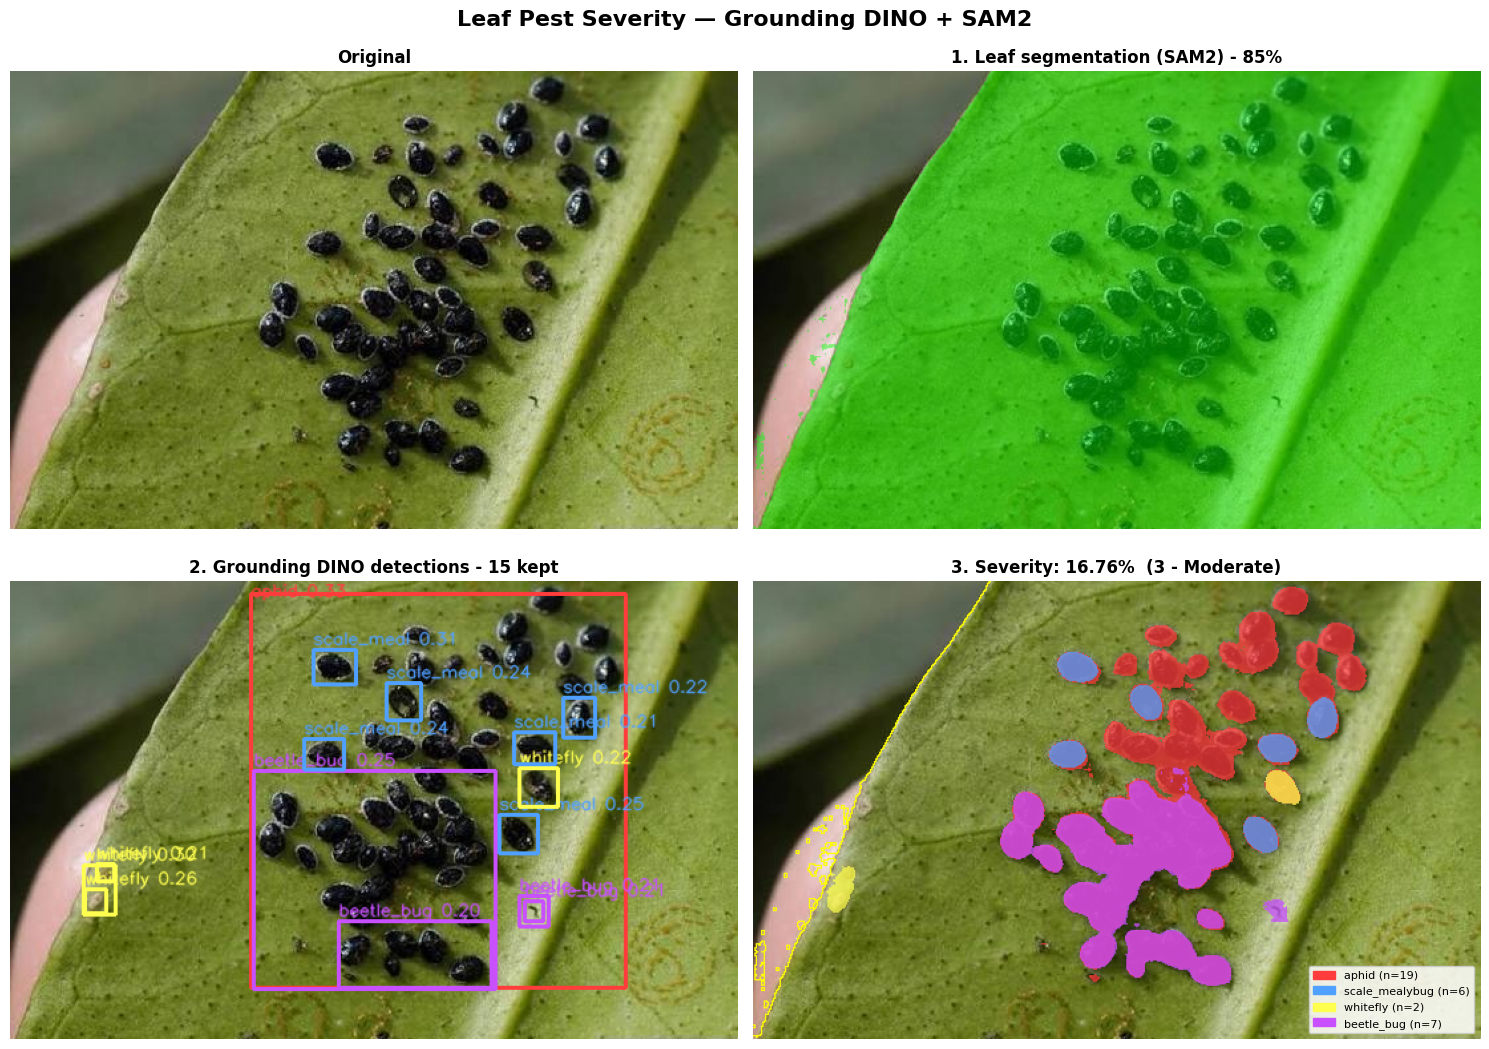

In [9]:
CLASS_COLORS = {
    "aphid":             (255,  60,  60),
    "whitefly":          (255, 255,  80),
    "scale_mealybug":    ( 80, 160, 255),
    "larva_caterpillar": (255, 140,   0),
    "beetle_bug":        (200,  80, 255),
    "egg_mass":          (  0, 230, 200),
    "lesion_spot":       (180,  70,  40),
    "rust_pustule":      (255, 170,  60),
    "chlorosis":         (230, 230, 100),
}

def show_results(rgb, leaf_mask, class_masks, class_counts, detections, severity):
    leaf_view = rgb.copy()
    leaf_view[leaf_mask] = (0.55 * leaf_view[leaf_mask] +
                            0.45 * np.array([0, 255, 0])).astype(np.uint8)

    det_view = rgb.copy()
    for d in detections:
        x1, y1, x2, y2 = d["box"]
        col = CLASS_COLORS.get(d["cls"], (255, 0, 0))
        cv2.rectangle(det_view, (x1, y1), (x2, y2), col, 2)
        cv2.putText(det_view, f"{d['cls'][:10]} {d['score']:.2f}",
                    (x1, max(12, y1 - 4)), cv2.FONT_HERSHEY_SIMPLEX,
                    0.42, col, 1, cv2.LINE_AA)

    mask_view = rgb.copy()
    for c, m in class_masks.items():
        col = np.array(CLASS_COLORS.get(c, (255, 0, 0)))
        mask_view[m] = (0.25 * mask_view[m] + 0.75 * col).astype(np.uint8)
    edges = cv2.dilate(leaf_mask.astype(np.uint8), np.ones((3, 3))) - leaf_mask
    mask_view[edges.astype(bool)] = [255, 255, 0]

    fig, ax = plt.subplots(2, 2, figsize=(15, 11))
    panels = [
        (rgb,       "Original"),
        (leaf_view, f"1. Leaf segmentation (SAM2) - {100*leaf_mask.mean():.0f}%"),
        (det_view,  f"2. Grounding DINO detections - {len(detections)} kept"),
        (mask_view, f"3. Severity: {severity:.2f}%  ({grade(severity)})"),
    ]
    for a, (im, t) in zip(ax.ravel(), panels):
        a.imshow(im)
        a.set_title(t, fontsize=12, fontweight="bold")
        a.axis("off")

    if class_masks:
        handles = [mpatches.Patch(color=np.array(CLASS_COLORS.get(c, (255,0,0)))/255,
                                  label=f"{c} (n={class_counts.get(c,0)})")
                   for c in class_masks]
        ax[1, 1].legend(handles=handles, loc="lower right", fontsize=8, framealpha=0.85)

    plt.suptitle("Leaf Pest Severity — Grounding DINO + SAM2", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()


show_results(rgb, leaf_mask, class_masks, class_counts, detections, severity)